# Project #2: Making Static and Interactive Data Visualization

In [1]:
import pandas as pd

In [2]:
# reading the csv file
df_population_raw = pd.read_csv("population_total.csv")

In [3]:
# first look at the dataset
df_population_raw.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


## 1. Making a Pivot Table

.pivot(): returns reshaped DataFrame organized by given index/column values ("pivot without aggregation")

In [4]:
# dropping null values
df_population_raw.dropna(inplace=True)

In [5]:
# making a pivot table
# want to make 'year' column to be the index
df_pivot = df_population_raw.pivot(index='year', columns="country", values="population")

In [6]:
# select some countries
df_pivot = df_pivot[['United States', 'India', 'China', 'Indonesia', 'Brazil']]

In [7]:
# showing pivot table
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


In [8]:
import matplotlib.pyplot as plt

## 2. Lineplot

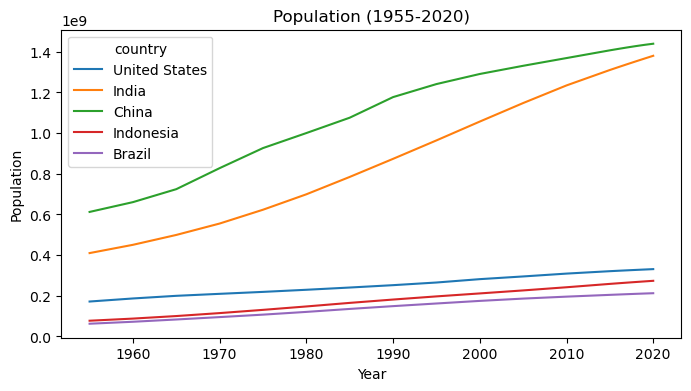

In [9]:
df_pivot.plot(kind="line", xlabel="Year", ylabel="Population", title="Population (1955-2020)", figsize=(8, 4))

# save plot
plt.savefig('my_test.png')

# show plot
plt.show()

In [10]:
df_pivot.to_excel('pivot_table.xlsx')

## 3. Barplot

### 3.1 Single Barplot

In [11]:
# selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]

In [12]:
# showing new dataframe
df_pivot_2020

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [13]:
# transpose dataframe from rows to columns or vice versa
df_pivot_2020 = df_pivot_2020.T

<Axes: title={'center': 'Population (2020'}, xlabel='Year', ylabel='Population'>

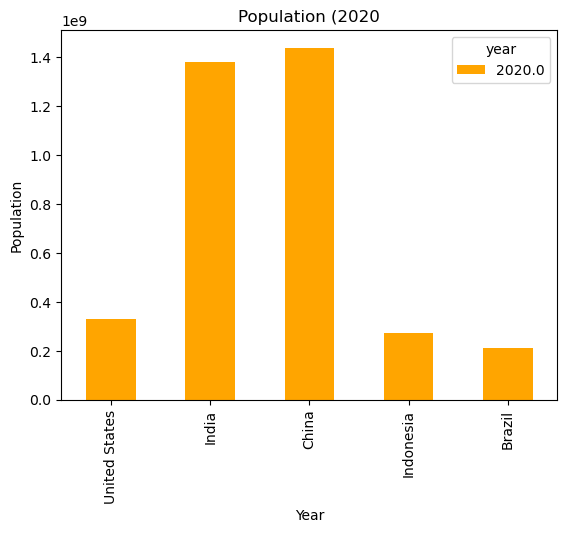

In [14]:
# making barplot
df_pivot_2020.plot(kind="bar", color="orange", xlabel="Year", ylabel="Population", title="Population (2020")

### 3.2 Barplot grouped by "n" variables

In [15]:
# selecting a few years
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]
df_pivot_sample

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


<Axes: xlabel='Year', ylabel='Population'>

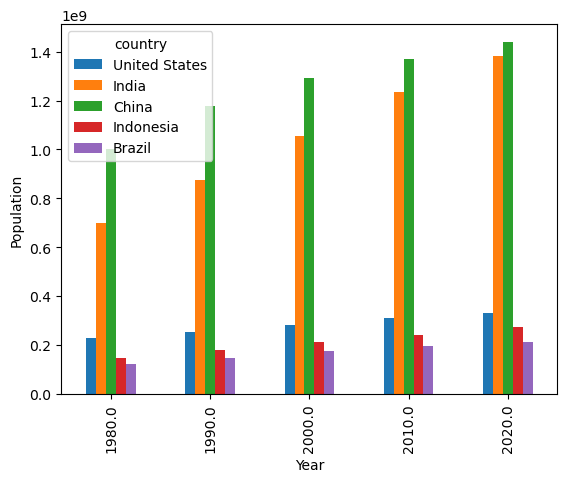

In [16]:
# making grouped barplot
df_pivot_sample.plot(kind="bar", xlabel="Year", ylabel="Population")

## 4. Piechart

In [17]:
# changing column name
df_pivot_2020.rename(columns={2020: '2020'}, inplace=True)
df_pivot_2020

year,2020
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


<Axes: title={'center': 'Population in 2020(%)'}, ylabel='2020'>

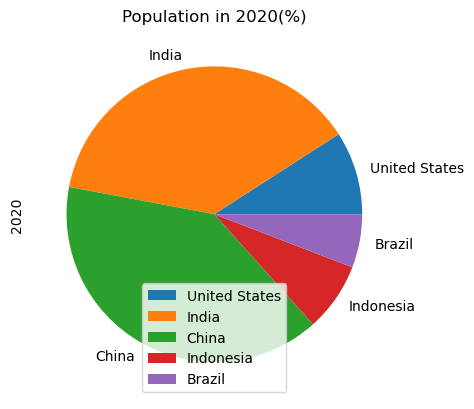

In [18]:
# making the plot
df_pivot_2020.plot(kind="pie", y='2020', title="Population in 2020(%)")

## 5. Boxplot

### 5.1 Single Boxplot

<Axes: ylabel='Population'>

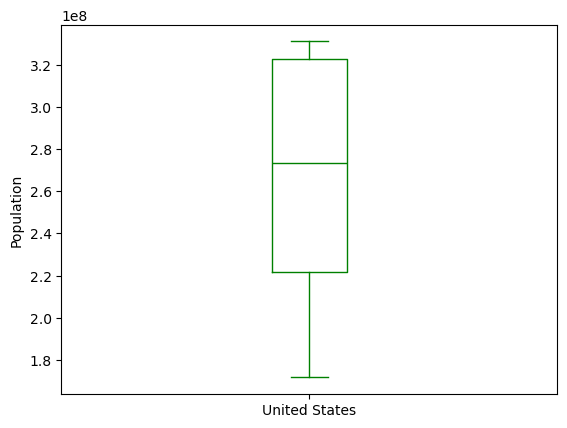

In [19]:
df_pivot["United States"].plot(kind="box", color="green", ylabel="Population")

### 5.2 Multiple Boxplot

<Axes: ylabel='Population'>

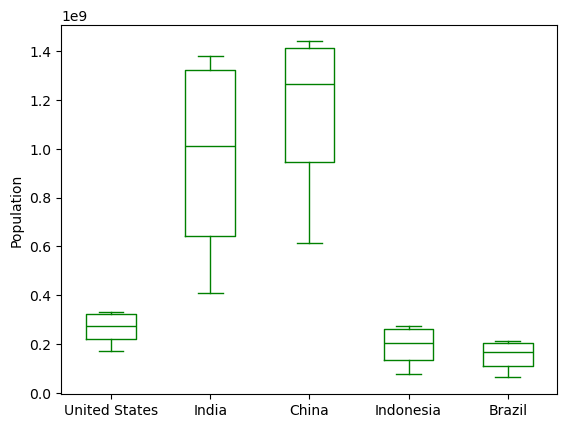

In [20]:
df_pivot.plot(kind="box", color="green", ylabel="Population")

## 6 Histogram

<Axes: ylabel='Frequency'>

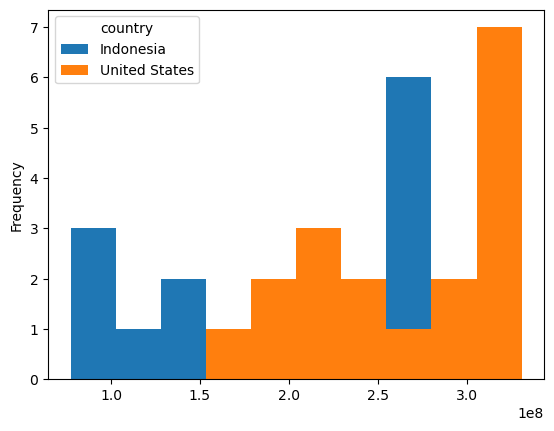

In [21]:
df_pivot[["Indonesia", "United States"]].plot(kind="hist")

## 7 ScatterPlot

In [22]:
# selecting a sample of the raw data
df_sample =  df_population_raw[df_population_raw['country'].isin(['United States', 'India', 'China', 'Indonesia', 'Brazil'])]

<Axes: xlabel='year', ylabel='population'>

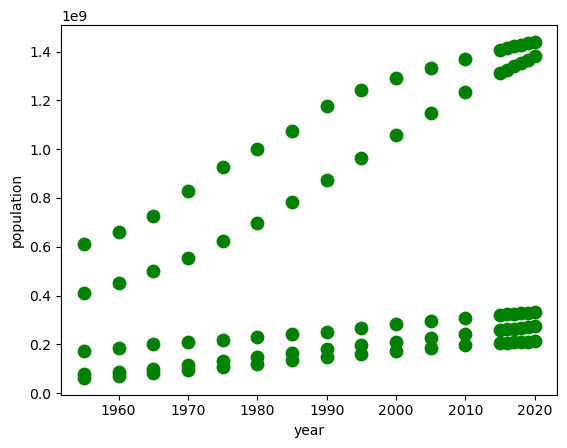

In [23]:
# creating the plot
df_sample.plot(kind="scatter", x = "year" , y="population", s=80, color="green" )

# Interactive Visualization with plotly

In [24]:
!pip install plotly

In [25]:
!pip install cufflinks

In [26]:
import pandas as pd
import cufflinks as cf
from IPython.display import display, HTML

cf.set_config_file(sharing="public", theme="ggplot", offline=True)

In [27]:
cf.getThemes()

['ggplot', 'pearl', 'solar', 'space', 'white', 'polar', 'henanigans']

In [28]:
df_population_raw = pd.read_csv("population_total.csv")
df_population_raw.head()

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09


In [29]:
# dropping null values
df_population_raw.dropna(inplace=True)

# making a pivot table
# want to make 'year' column to be the index
df_pivot = df_population_raw.pivot(index='year', columns="country", values="population")

# select some countries
df_pivot = df_pivot[['United States', 'India', 'China', 'Indonesia', 'Brazil']]

# showing the pivot table
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


## 1. Interactive Lineplot

In [35]:
#import numpy as np
#color = "rgba(226, 74, 51, 1.0)"

#df_pivot.iplot(kind="line")

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of scatter.line
        Received value: 'rgba(226, 74, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list

In [36]:
import pandas as pd
import numpy as np
import cufflinks as cf
import plotly.offline as pyo

# Set up Plotly + Cufflinks
pyo.init_notebook_mode(connected=True)
cf.go_offline()

# Create sample DataFrame
df = pd.DataFrame({
    'A': np.random.randn(100).cumsum(),
    'B': np.random.randn(100).cumsum()
})

# Plot line chart
df.iplot(kind='line', title='Simple Line Plot', xTitle='Index', yTitle='Value')

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of scatter.line
        Received value: 'rgba(226, 74, 51, np.float64(1.0))'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list